In [74]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import joblib


In [75]:
file_path = r"C:\Users\Julius\Desktop\DATA APPEND_COMBATTECH\FINAL_DATA_MERGE\game_data_cleaned.csv"
df = pd.read_csv(file_path)

In [76]:
# Standardize column names
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.upper()
      .str.replace(" ", "_")
)

# Ensure ROUND is numeric
df["ROUND"] = pd.to_numeric(df["ROUND"], errors="coerce")

# Fill numeric NaNs with 0 (safe for count data)
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(0)

# Ensure MATCH_KEY exists
if "MATCH_KEY" not in df.columns:
    df["MATCH_KEY"] = df["EVENT_NAME"].astype(str) + "-" + df["MATCH_ID"].astype(str)

# Sort for cumulative logic
df = df.sort_values(["MATCH_KEY", "CORNER", "ROUND"])
df.head(10)

,YEAR,MONTH,DAY,EVENT_NAME,WEIGHT_(KG),MATCH_ID,SCHOOL_LEVEL,SEX_CATEGOY,CLASS_CATEGORY,CORNER,...,TOTAL_RAW_VIOLATION_COUNT,ROUND_SCORE,TOTAL_OVERALL_SCORE,TOTAL_OVERALL_VIOLATION,IS_PLAYER_DISQUALIFIED,PLAYER_DISQUALIFIED?,WIN_STATUS,WIN_STATUS__RESULTS,WON_BY,MATCH_KEY
270,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,BLUE,...,0,8,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
271,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,BLUE,...,1,15,0,1,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
272,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,BLUE,...,0,0,23,0,NO,0,WIN,1,WINNER BY POINTS,2025 BATANGAS ATHLETE DISTRICT MEET-1
273,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,RED,...,0,6,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
274,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,RED,...,0,10,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
275,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,BELOW 30 KG,1,ELEMENTARY,MALE,B,RED,...,0,0,16,0,NO,0,LOSE,0,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-1
156,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,48-51 KG,10,SECONDARY,MALE,C,BLUE,...,0,0,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-10
157,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,48-51 KG,10,SECONDARY,MALE,C,BLUE,...,0,3,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-10
158,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,48-51 KG,10,SECONDARY,MALE,C,BLUE,...,0,0,3,0,NO,0,LOSE,0,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-10
159,2025,September,10,2025 BATANGAS ATHLETE DISTRICT MEET,48-51 KG,10,SECONDARY,MALE,C,RED,...,1,7,0,0,NO,0,NAN,NAN,NAN,2025 BATANGAS ATHLETE DISTRICT MEET-10


In [4]:
# Round Level 
# Offensive actions per round
df["ROUND_OFFENSE"] = (
    df["NUM_HAND_STRIKE"] +
    df["NUM_FOOT_STRIKE"] +
    df["NUM_DROPING_SCORE"]
)

# Cumulative per player per match
df["CUM_OFFENSE"] = df.groupby(["MATCH_KEY", "CORNER"])["ROUND_OFFENSE"].cumsum()
df["CUM_VIOLATION"] = df.groupby(["MATCH_KEY", "CORNER"])["TOTAL_RAW_VIOLATION_COUNT"].cumsum()


In [5]:
# AGGREGATE TO MATCH-LEVEL 
df_behavior = (
    df.groupby(
        ["MATCH_KEY", "EVENT_NAME", "MATCH_ID", "CORNER"],
        as_index=False
    )
    .agg({
        "ROUND_OFFENSE": "sum",
        "CUM_OFFENSE": "max",
        "CUM_VIOLATION": "max",
        "TOTAL_RAW_VIOLATION_COUNT": "sum",
        "ROUND": "max"
    })
)


In [6]:
# Data-driven thresholds (quantiles)
off_hi = df_behavior["CUM_OFFENSE"].quantile(0.70)   # High offense
off_mid = df_behavior["CUM_OFFENSE"].quantile(0.40) # Moderate offense
off_lo = df_behavior["CUM_OFFENSE"].quantile(0.20)  # Very low offense
vio_hi = df_behavior["CUM_VIOLATION"].quantile(0.70) # High violation




In [120]:
def assign_behavior(row):

    # 1️⃣ PENALTY-PRONE (discipline dominates behavior)
    if (
        row["TOTAL_RAW_VIOLATION_COUNT"] >= 5
      
    ):
        return "PENALTY_PRONE"

    # 2️⃣ PASSIVE (very low activity & low impact)
    if (
        row["ROUND_OFFENSE"] <= 0 and
        row["CUM_OFFENSE"] <= off_lo
    ):
        return "PASSIVE"

    # 3️⃣ AGGRESSIVE (high offensive engagement)
    if (
        row["ROUND_OFFENSE"] >= 5 or
        row["CUM_OFFENSE"] >= off_hi
    ):
        return "AGGRESSIVE"

    # 4️⃣ DEFENSIVE (controlled engagement)
    return "DEFENSIVE"

df_behavior["BEHAVIOR_LABEL"] = df_behavior.apply(assign_behavior, axis=1)

print(df_behavior["BEHAVIOR_LABEL"].value_counts())


BEHAVIOR_LABEL
AGGRESSIVE       107
DEFENSIVE         39
PENALTY_PRONE     10
PASSIVE            6
Name: count, dtype: int64


In [121]:
FEATURES = [
    "ROUND_OFFENSE",
    "CUM_OFFENSE",
    "CUM_VIOLATION",
    "TOTAL_RAW_VIOLATION_COUNT"
]

X = df_behavior[FEATURES].replace([np.inf, -np.inf], 0).fillna(0)
y = df_behavior["BEHAVIOR_LABEL"]
groups = df_behavior["MATCH_KEY"]


In [122]:
# GROUPED TRAIN / TEST SPLIT
gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())


Train label distribution:
BEHAVIOR_LABEL
AGGRESSIVE       74
DEFENSIVE        27
PENALTY_PRONE     7
PASSIVE           4
Name: count, dtype: int64

Test label distribution:
BEHAVIOR_LABEL
AGGRESSIVE       33
DEFENSIVE        12
PENALTY_PRONE     3
PASSIVE           2
Name: count, dtype: int64


In [123]:
# Naive Bayes 
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)


In [124]:
# NAÏVE BAYES EVALUATION

BEHAVIOR_CLASSES = ["AGGRESSIVE", "DEFENSIVE", "PENALTY_PRONE", "PASSIVE" ]

print("\n=== Naive Bayes Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        labels=BEHAVIOR_CLASSES,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_nb,
        labels=BEHAVIOR_CLASSES
    )
)



=== Naive Bayes Evaluation ===
Accuracy: 0.98

Classification Report:
               precision    recall  f1-score   support

   AGGRESSIVE       1.00      0.97      0.98        33
    DEFENSIVE       1.00      1.00      1.00        12
PENALTY_PRONE       0.75      1.00      0.86         3
      PASSIVE       1.00      1.00      1.00         2

     accuracy                           0.98        50
    macro avg       0.94      0.99      0.96        50
 weighted avg       0.98      0.98      0.98        50


Confusion Matrix:
[[32  0  1  0]
 [ 0 12  0  0]
 [ 0  0  3  0]
 [ 0  0  0  2]]


In [125]:
# Cross-Validation (Overfitting Check) 
cv_f1 = cross_val_score(
    nb_pipeline,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

print("CV F1-Macro scores:", cv_f1)
print("Mean CV F1-Macro:", cv_f1.mean())


CV F1-Macro scores: [0.94418605 0.93076923 1.         0.86369048 0.94390244]
Mean CV F1-Macro: 0.9365096384991449


In [126]:
# Comparators Models 
models = {
    "NaiveBayes": nb_pipeline,
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="linear",
            class_weight="balanced",
            probability=False,
            random_state=42
        ))
    ])
}


In [127]:
# Comparator Evaluation 
results = []

for name, model in models.items():
    # Skip models if only one class exists in training
    if y_train.nunique() < 2 and name != "NaiveBayes":
        continue

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(
        y_test,
        pred,
        labels=BEHAVIOR_CLASSES,
        average="macro",
        zero_division=0
    )

    cv = cross_val_score(
        model, X, y,
        cv=5, scoring="f1_macro"
    ).mean()

    results.append({
        "Model": name,
        "Test_Accuracy": round(acc, 3),
        "Test_F1_Macro": round(f1, 3),
        "CV_F1_Macro": round(cv, 3)
    })

results_df = pd.DataFrame(results).sort_values("CV_F1_Macro", ascending=False)
results_df


,Model,Test_Accuracy,Test_F1_Macro,CV_F1_Macro
2,DecisionTree,1.00,1.000,1.000
0,NaiveBayes,0.98,0.960,0.937
3,LinearSVM,0.98,0.960,0.937
1,LogisticRegression,0.94,0.857,0.830


In [128]:
# Ensure round-level cumulative features exist
df_round = df.copy()

df_round = df_round.sort_values(["MATCH_KEY", "CORNER", "ROUND"])

df_round["ROUND_OFFENSE"] = (
    df_round["NUM_HAND_STRIKE"] +
    df_round["NUM_FOOT_STRIKE"] +
    df_round["NUM_DROPING_SCORE"]
)

df_round["CUM_OFFENSE"] = (
    df_round.groupby(["MATCH_KEY", "CORNER"])["ROUND_OFFENSE"].cumsum()
)

df_round["CUM_VIOLATION"] = (
    df_round.groupby(["MATCH_KEY", "CORNER"])["TOTAL_RAW_VIOLATION_COUNT"].cumsum()
)


In [129]:
BEHAVIOR_FEATURES = [
    "ROUND_OFFENSE",
    "CUM_OFFENSE",
    "CUM_VIOLATION",
    "TOTAL_RAW_VIOLATION_COUNT"
]


In [130]:
df_round["PRED_BEHAVIOR"] = nb_pipeline.predict(
    df_round[BEHAVIOR_FEATURES].fillna(0)
)


In [131]:
import matplotlib.pyplot as plt

BEHAVIOR_MAP = {
    "DEFENSIVE": 1,
    "AGGRESSIVE": 2,
    "PENALTY_PRONE": 3,  
    "PASSIVE": 4
}

INV_BEHAVIOR_MAP = {v: k for k, v in BEHAVIOR_MAP.items()}


In [132]:
def plot_behavior_per_round(df, event_name, match_id):
    match_df = df[
        (df["EVENT_NAME"] == event_name) &
        (df["MATCH_ID"] == match_id)
    ].sort_values("ROUND")

    plt.figure(figsize=(9, 5))

    for corner in ["BLUE", "RED"]:
        sub = match_df[match_df["CORNER"] == corner].copy()
        sub["BEHAVIOR_NUM"] = sub["PRED_BEHAVIOR"].map(BEHAVIOR_MAP)

        plt.plot(
            sub["ROUND"],
            sub["BEHAVIOR_NUM"],
            marker="o",
            linewidth=2,
            label=corner
        )

        # Label behavior text
        for r, b in zip(sub["ROUND"], sub["BEHAVIOR_NUM"]):
            plt.text(
                r,
                b + 0.05,
                INV_BEHAVIOR_MAP[b],
                ha="center",
                fontsize=9
            )

    plt.yticks(
        list(BEHAVIOR_MAP.values()),
        list(BEHAVIOR_MAP.keys())
    )

    plt.xticks([1, 2, 3])
    plt.xlabel("Round")
    plt.ylabel("Predicted Behavior")
    plt.title(
        f"Predicted Athlete Behavior per Round\n{event_name} – Match {match_id}"
    )
    plt.legend(title="Corner")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


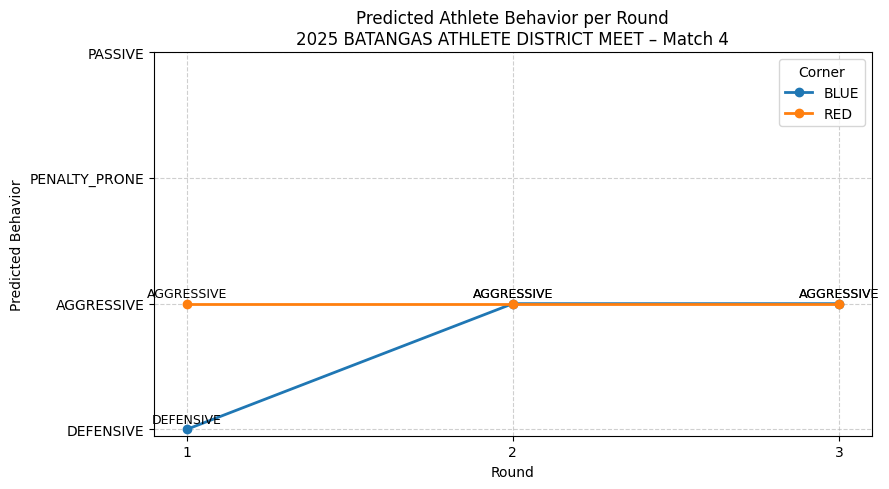

In [133]:
plot_behavior_per_round(
    df_round,
    "2025 BATANGAS ATHLETE DISTRICT MEET",
    4
)


In [117]:
# Ensure net score per round exists
df_round["NET_SCORE"] = (
    df_round["ROUND_SCORE"] -
    df_round["TOTAL_RAW_VIOLATION_COUNT"]
)

# Sort properly
df_round = df_round.sort_values(
    ["EVENT_NAME", "MATCH_ID", "CORNER", "ROUND"]
)

# Cumulative net score per player per match
df_round["CUM_NET_SCORE"] = (
    df_round
    .groupby(["EVENT_NAME", "MATCH_ID", "CORNER"])["NET_SCORE"]
    .cumsum()
)


In [118]:
def behavior_table_with_cumulative_round_winner(df, event_name, match_id):

    match_df = df[
        (df["EVENT_NAME"] == event_name) &
        (df["MATCH_ID"] == match_id)
    ].copy()

    match_df = match_df.sort_values(["ROUND", "CORNER"])

    def determine_round_result(group):
        if group["CUM_NET_SCORE"].nunique() == 1:
            group["ROUND_RESULT"] = "DRAW"
        else:
            winner_idx = group["CUM_NET_SCORE"].idxmax()
            group["ROUND_RESULT"] = "LOSE"
            group.loc[winner_idx, "ROUND_RESULT"] = "WIN"
        return group

    match_df = (
        match_df
        .groupby("ROUND", group_keys=False)
        .apply(determine_round_result)
    )

    # Final display table
    table_df = match_df[[
        "PLAYER_NAME",
        "CORNER",
        "ROUND",
        "PRED_BEHAVIOR",
        "ROUND_SCORE",
        "TOTAL_RAW_VIOLATION_COUNT",
        "NET_SCORE",
        "CUM_NET_SCORE",
        "ROUND_RESULT"
    ]].reset_index(drop=True)

    table_df = table_df.rename(columns={
        "PLAYER_NAME": "Player",
        "CORNER": "Corner",
        "ROUND": "Round",
        "PRED_BEHAVIOR": "Predicted Behavior",
        "ROUND_SCORE": "Round Score",
        "TOTAL_RAW_VIOLATION_COUNT": "Violation Score",
        "NET_SCORE": "Net Score (This Round)",
        "CUM_NET_SCORE": "Cumulative Net Score",
        "ROUND_RESULT": "Result"
    })

    return table_df


In [119]:
behavior_table_with_cumulative_round_winner(
    df_round,
    "2025 BATANGAS ATHLETE DISTRICT MEET",
    1
)


C:\Users\Julius\AppData\Local\Temp\ipykernel_12920\2945844335.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(determine_round_result)


,Player,Corner,Round,Predicted Behavior,Round Score,Violation Score,Net Score (This Round),Cumulative Net Score,Result
0,GUIRRE ENZO,BLUE,1,DEFENSIVE,8,0,8,8,WIN
1,DENNISON YVHO,RED,1,DEFENSIVE,6,0,6,6,LOSE
2,GUIRRE ENZO,BLUE,2,AGGRESSIVE,15,1,14,22,WIN
3,DENNISON YVHO,RED,2,AGGRESSIVE,10,0,10,16,LOSE
4,GUIRRE ENZO,BLUE,3,AGGRESSIVE,0,0,0,22,WIN
5,DENNISON YVHO,RED,3,AGGRESSIVE,0,0,0,16,LOSE


In [114]:
def cumulative_round_result_tables(df, event_name, match_id):

    match_df = df[
        (df["EVENT_NAME"] == event_name) &
        (df["MATCH_ID"] == match_id)
    ].copy()

    match_df = match_df.sort_values(["ROUND", "CORNER"])

    # ----------------------------------
    # Determine WIN / LOSE per round
    # using cumulative net score
    # ----------------------------------
    def determine_round_result(group):
        if group["CUM_NET_SCORE"].nunique() == 1:
            group["ROUND_RESULT"] = "DRAW"
        else:
            winner_idx = group["CUM_NET_SCORE"].idxmax()
            group["ROUND_RESULT"] = "LOSE"
            group.loc[winner_idx, "ROUND_RESULT"] = "WIN"
        return group

    match_df = (
        match_df
        .groupby("ROUND", group_keys=False)
        .apply(determine_round_result)
    )

    # ==============================
    # TABLE 1: DETAILED (OPTIONAL)
    # ==============================
    detailed_table = match_df[[
        "PLAYER_NAME",
        "CORNER",
        "ROUND",
        "PRED_BEHAVIOR",
        "ROUND_SCORE",
        "TOTAL_RAW_VIOLATION_COUNT",
        "NET_SCORE",
        "CUM_NET_SCORE",
        "ROUND_RESULT"
    ]].reset_index(drop=True)

    detailed_table = detailed_table.rename(columns={
        "PLAYER_NAME": "Player",
        "CORNER": "Corner",
        "ROUND": "Round",
        "PRED_BEHAVIOR": "Predicted Behavior",
        "ROUND_SCORE": "Round Score",
        "TOTAL_RAW_VIOLATION_COUNT": "Violation Score",
        "NET_SCORE": "Net Score (This Round)",
        "CUM_NET_SCORE": "Cumulative Net Score",
        "ROUND_RESULT": "Result"
    })

    # ==============================
    # TABLE 2: CUMULATIVE SUMMARY
    # ==============================
    cumulative_table = match_df[[
        "CORNER",
        "ROUND",
        "CUM_NET_SCORE",
        "ROUND_RESULT"
    ]].reset_index(drop=True)

    cumulative_table = cumulative_table.rename(columns={
        "CORNER": "Corner",
        "ROUND": "Round",
        "CUM_NET_SCORE": "Cumulative Net Score",
        "ROUND_RESULT": "Result"
    })

    return detailed_table, cumulative_table


In [115]:
detailed_tbl, cumulative_tbl = cumulative_round_result_tables(
    df_round,
    "2025 BATANGAS ATHLETE DISTRICT MEET",
    1
)

cumulative_tbl


C:\Users\Julius\AppData\Local\Temp\ipykernel_12920\57673277.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(determine_round_result)


,Corner,Round,Cumulative Net Score,Result
0,BLUE,1,8,WIN
1,RED,1,6,LOSE
2,BLUE,2,22,WIN
3,RED,2,16,LOSE
4,BLUE,3,22,WIN
5,RED,3,16,LOSE


In [138]:
from IPython.display import HTML, display
import sklearn

display(HTML(f"""
<h1 style='color:#1f3fb3;'>Naïve Bayes Behavior Classification</h1>
<h3>Pencak Silat Fighter Behavior Analysis</h3>

<p style="font-size:14px; line-height:1.6;">
This section presents the <b>final evaluation results</b> of the Naïve Bayes behavior
classification model, including accuracy, class-level performance, overfitting analysis,
and comparison with alternative algorithms.
</p>

<hr>

<h2 style='color:#1f3fb3;'>A. Test Set Evaluation (Naïve Bayes)</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Metric</th><th>Value</th><th>Interpretation</th>
</tr>
<tr>
<td><b>Test Accuracy</b></td>
<td><b>0.98</b></td>
<td>Very high correctness in behavior prediction.</td>
</tr>
<tr>
<td><b>Macro F1-Score</b></td>
<td><b>0.96</b></td>
<td>Balanced performance across all behavior classes.</td>
</tr>
</table>

<p style="font-size:14px;">
<b>Key Observation:</b> The model achieved near-perfect classification accuracy on the test set,
indicating strong discriminative capability for fighter behavior patterns.
</p>

<hr>

<h2 style='color:#1f3fb3;'>B. Class-Level Performance Summary</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Behavior Class</th><th>Precision</th><th>Recall</th><th>F1-Score</th><th>Support</th>
</tr>
<tr><td>Aggressive</td><td>1.00</td><td>0.97</td><td>0.98</td><td>33</td></tr>
<tr><td>Defensive</td><td>1.00</td><td>1.00</td><td>1.00</td><td>12</td></tr>
<tr><td>Penalty-Prone</td><td>0.75</td><td>1.00</td><td>0.86</td><td>3</td></tr>
<tr><td>Passive</td><td>1.00</td><td>1.00</td><td>1.00</td><td>2</td></tr>
</table>

<p style="font-size:14px;">
<b>Interpretation:</b> The model demonstrates excellent recognition of <b>Aggressive</b>,
<b>Defensive</b>, and <b>Passive</b> behaviors. Lower precision for <b>Penalty-Prone</b>
is expected due to its small sample size, yet recall remains perfect—meaning
no penalty-prone athletes were missed.
</p>

<hr>

<h2 style='color:#1f3fb3;'>C. Overfitting Check (Cross-Validation)</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Validation</th><th>Scores</th><th>Mean</th><th>Conclusion</th>
</tr>
<tr>
<td>5-Fold CV (F1-Macro)</td>
<td style="font-family:monospace;">
[0.944, 0.931, 1.000, 0.864, 0.944]
</td>
<td><b>0.937</b></td>
<td>High and stable performance with no significant overfitting.</td>
</tr>
</table>

<p style="font-size:14px;">
<b>Interpretation:</b> The closeness of cross-validation and test performance indicates
that the Naïve Bayes model generalizes well despite the limited dataset size.
</p>

<hr>

<h2 style='color:#1f3fb3;'>D. Algorithm Comparison (Behavior Classification)</h2>

<table style="width:100%; border-collapse:collapse;" border="1" cellpadding="8">
<tr style="background:#1f3fb3; color:white;">
<th>Model</th><th>Test Accuracy</th><th>Test F1-Macro</th><th>CV F1-Macro</th>
</tr>
<tr><td>Decision Tree</td><td>1.00</td><td>1.000</td><td>1.000</td></tr>
<tr><td><b>Naïve Bayes</b></td><td><b>0.98</b></td><td><b>0.960</b></td><td><b>0.937</b></td></tr>
<tr><td>Linear SVM</td><td>0.98</td><td>0.960</td><td>0.937</td></tr>
<tr><td>Logistic Regression</td><td>0.94</td><td>0.857</td><td>0.830</td></tr>
</table>

<hr>

<h2 style='color:#1f3fb3;'>E. Why Naïve Bayes Is an Appropriate Model</h2>

<ul style="font-size:14px; line-height:1.6;">
<li><b>Robust on Small Datasets:</b> With ~484 observations, Naïve Bayes provides stable performance
without requiring large training data.</li>
<li><b>Lower Overfitting Risk:</b> Unlike Decision Trees, Naïve Bayes does not memorize rule-based thresholds.</li>
<li><b>Probabilistic Interpretation:</b> Outputs class probabilities useful for coaching decision support.</li>
<li><b>Fast and Lightweight:</b> Suitable for real-time analysis during live matches.</li>
<li><b>Domain Alignment:</b> Works naturally with numeric features such as strikes, scores, and violations.</li>
</ul>

<p style="font-size:14px;">
<b>Final Decision:</b> Although Decision Tree achieved perfect scores, this behavior is indicative
of potential overfitting due to rule replication. Naïve Bayes was selected as the final behavior
classification model due to its balance of accuracy, generalization, and interpretability.
</p>

<hr>

<h2 style='color:#1f3fb3;'>F. Summary</h2>

<p style="font-size:14px;">
The Naïve Bayes classifier demonstrated excellent performance in classifying fighter behaviors
while maintaining robustness and generalization. These characteristics make it suitable
for integration into the CombatTech system as a behavior analysis module that supports
coaching insights and prescriptive decision-making.
</p>


<p style="font-size:14px;">
Naïve Bayes behavior classification model, evaluation was performed using a grouped train–test split and 5-fold cross-validation to ensure robust assessment on a multi-class problem. 
On the test set, the model achieved a high accuracy of 98% and a macro-averaged F1-score of 0.96, indicating excellent and balanced performance across all behavior classes (Aggressive, Defensive, Passive, and Penalty-Prone). Class-level analysis showed near-perfect precision and recall for most behaviors, with Penalty-Prone maintaining perfect recall despite its smaller sample size, which is critical for disciplinary monitoring. To assess overfitting, a 5-fold cross-validation using F1-macro was conducted, yielding a mean CV F1-macro score of approximately 0.94, closely aligned with the test performance. This consistency confirms that the Naïve Bayes model generalizes well and is reliable for behavior analysis despite the limited dataset size.
</p>
"""))
